# GodelEnv 2.0 - Training Evidence Notebook

This notebook runs the same compact-action training pipeline as `train.py`.
GodelEnv is a recursive self-improvement environment where the agent can either
improve the current answer directly or propose a `StrategyPatch` that mutates
its own reasoning policy.

Pipeline:
1. Collect prompts from the live environment
2. Build a heuristic warm-start dataset
3. Train a tiny local model with SFT
4. Refine with GRPO
5. Export loss, reward, and before/after plots plus a metrics JSON summary

Reproducibility notes:
- The notebook defaults to deterministic grading and strategy evaluation.
- The tiny local model emits compact action tokens that the environment expands
  into full actions before verification.
- For the stronger hybrid path, switch the modes below from `deterministic` to `auto`.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

from dotenv import load_dotenv


load_dotenv(override=False)
os.environ.setdefault("WANDB_DISABLED", "true")
os.environ.setdefault("WANDB_MODE", "disabled")
os.environ.setdefault("TRL_EXPERIMENTAL_SILENCE", "1")


def _in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ


if _in_colab() and not (Path.cwd() / "pyproject.toml").exists():
    repo_dir = Path("/content/GodelEnv")
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/dwan-ith/GodelEnv.git", str(repo_dir)],
            check=True,
        )
    os.chdir(repo_dir)

if _in_colab():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", ".[train]"],
        check=True,
    )


def _restart_with_utf8_on_windows() -> None:
    # TRL reads some packaged templates via Path.read_text() without an explicit
    # encoding; on Windows this can default to cp1252 and crash with UnicodeDecodeError.
    # The simplest robust fix for script execution is to restart with UTF-8 mode
    # enabled. Inside a notebook kernel, restarting via sys.argv exits the cell,
    # so we skip the restart there.
    if os.name != "nt":
        return
    if os.environ.get("PYTHONUTF8") == "1":
        return
    if "ipykernel" in sys.modules:
        return

    env = os.environ.copy()
    env["PYTHONUTF8"] = "1"
    completed = subprocess.run([sys.executable, *sys.argv], env=env, check=False)
    raise SystemExit(completed.returncode)


_restart_with_utf8_on_windows()


def _force_utf8_path_reads_on_windows() -> None:
    if os.name != "nt":
        return
    if os.environ.get("PYTHONUTF8") == "1":
        return
    if getattr(Path, "_godel_utf8_patch", False):
        return

    original_read_text = Path.read_text

    def _read_text(self, *args, **kwargs):
        if not args and "encoding" not in kwargs:
            kwargs["encoding"] = "utf-8"
        return original_read_text(self, *args, **kwargs)

    Path.read_text = _read_text
    Path._godel_utf8_patch = True


_force_utf8_path_reads_on_windows()

from godel_engine.rollout import collect_local_prompt_dataset
from godel_engine.training_support import (
    build_supervised_examples,
    build_tiny_model,
    evaluate_model,
    load_tokenizer,
    plot_before_after,
    plot_training_curves,
    run_grpo,
    run_sft,
)

## 1. Configure the Run

In [2]:
TASKS = ["factual_qa", "alignment_qa", "reasoning", "strategy_optimization"]
NUM_PROMPTS = 16
SFT_STEPS = 20
GRPO_STEPS = 10
MAX_INPUT_LENGTH = 512
MAX_NEW_TOKENS = 1
OUTPUT_DIR = Path("artifacts/training_run")
GRADING_MODE = os.getenv("GODEL_GRADING_MODE", "deterministic")
STRATEGY_EVAL_MODE = os.getenv("GODEL_STRATEGY_EVAL_MODE", "deterministic")
os.environ["GODEL_GRADING_MODE"] = GRADING_MODE
os.environ["GODEL_STRATEGY_EVAL_MODE"] = STRATEGY_EVAL_MODE
print(f"Training config: {NUM_PROMPTS} prompts, {SFT_STEPS} SFT steps, {GRPO_STEPS} GRPO steps")
print(f"Modes: grading={GRADING_MODE}, strategy_eval={STRATEGY_EVAL_MODE}")

Training config: 16 prompts, 20 SFT steps, 10 GRPO steps
Modes: grading=deterministic, strategy_eval=deterministic


## 2. Collect Prompts and Build the Warm-Start Dataset

In [3]:
prompt_data = collect_local_prompt_dataset(
    num_prompts=NUM_PROMPTS,
    tasks=TASKS,
    seed=42,
)
supervised_examples = build_supervised_examples(prompt_data)

print(f"Collected {len(prompt_data)} prompts across {len(TASKS)} task families")
for task in TASKS:
    count = sum(1 for prompt in prompt_data if prompt["task_type"] == task)
    print(f"  {task}: {count} prompts")

Collected 16 prompts across 4 task families
  factual_qa: 4 prompts
  alignment_qa: 4 prompts
  reasoning: 4 prompts
  strategy_optimization: 4 prompts


## 3. Build the Tiny Local Model

We use a 2-layer GPT-2 proof-of-concept model for the local CPU run.
To keep the action space learnable, the model emits compact action tokens
that expand into full environment actions before scoring.
For larger-scale training, replace this with Unsloth + a stronger instruct model.

In [4]:
tokenizer = load_tokenizer()
model = build_tiny_model(
    tokenizer,
    max_length=max(MAX_INPUT_LENGTH + MAX_NEW_TOKENS + 64, 384),
)
total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Model: GPT-2 tiny ({total_params:,} parameters)")

C:\Users\aacer\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model: GPT-2 tiny (6,903,936 parameters)


## 4. Baseline Evaluation (Before Training)

In [5]:
baseline_metrics = evaluate_model(
    model,
    tokenizer,
    prompt_data,
    max_new_tokens=MAX_NEW_TOKENS,
    max_input_length=MAX_INPUT_LENGTH,
    policy_mode="random",
    seed=42,
)
print(
    f"Baseline: mean_reward={baseline_metrics['mean_reward']:.4f}, "
    f"mean_score={baseline_metrics['mean_score']:.4f}"
)
print(
    "Structured policy: "
    f"structured_action_rate={baseline_metrics.get('structured_action_rate', 0.0):.2%}, "
    "Patch behavior: "
    f"proposal_rate={baseline_metrics.get('strategy_patch_rate', 0.0):.2%}, "
    f"acceptance_rate={baseline_metrics.get('patch_acceptance_rate', 0.0):.2%}, "
    f"mean_patch_delta={baseline_metrics.get('mean_patch_improvement', 0.0):+.4f}"
)
for episode in baseline_metrics["episodes"][:4]:
    print(
        f"  {episode['task_type']:25s} "
        f"score={episode['score']:.3f}  reward={episode['reward']:+.3f}"
    )

Baseline: mean_reward=0.3873, mean_score=0.7364
Structured policy: structured_action_rate=100.00%, Patch behavior: proposal_rate=12.50%, acceptance_rate=0.00%, mean_patch_delta=+0.0000
  factual_qa                score=1.000  reward=+0.140
  alignment_qa              score=0.718  reward=+0.536
  reasoning                 score=0.167  reward=+0.015
  strategy_optimization     score=0.868  reward=-0.076


## 5. Warm-Start with Supervised Traces (SFT)

The warm start teaches the tiny model the compact action format and the
basic alignment between prompt type and action choice.

In [6]:
sft_logs = run_sft(
    model,
    tokenizer,
    supervised_examples,
    output_dir=OUTPUT_DIR / "sft",
    max_steps=SFT_STEPS,
    batch_size=1,
    max_length=MAX_INPUT_LENGTH,
    use_cpu=True,
)
sft_loss_entries = [item for item in sft_logs if "loss" in item]
print(f"SFT complete: {len(sft_loss_entries)} steps logged")
if sft_loss_entries:
    print(f"  Initial loss: {sft_loss_entries[0]['loss']:.4f}")
    print(f"  Final loss:   {sft_loss_entries[-1]['loss']:.4f}")

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

Map: 100%|██████████| 16/16 [00:00<00:00, 157.15 examples/s]

Map: 100%|██████████| 16/16 [00:00<00:00, 143.80 examples/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
1,10.805300
2,10.796700
3,10.757900
4,10.768500
5,10.694700
6,10.712600
7,10.645000
8,10.661700
9,10.607000
10,10.657200


SFT complete: 20 steps logged
  Initial loss: 10.8053
  Final loss:   10.5701


## 6. Refine with Group Relative Policy Optimization (GRPO)

GRPO uses the environment reward directly. The local rollout samples among the
allowed compact action tokens, expands them into real actions, and updates the
policy toward higher-reward choices.

In [7]:
grpo_logs = run_grpo(
    model,
    tokenizer,
    prompt_data,
    output_dir=OUTPUT_DIR / "grpo",
    max_steps=GRPO_STEPS,
    batch_size=2,
    num_generations=2,
    max_completion_length=MAX_NEW_TOKENS,
    max_new_tokens=MAX_NEW_TOKENS,
    use_cpu=True,
)
grpo_reward_entries = [item for item in grpo_logs if "reward" in item]
print(f"GRPO complete: {len(grpo_reward_entries)} steps logged")
if grpo_reward_entries:
    print(f"  Initial reward: {grpo_reward_entries[0]['reward']:.4f}")
    print(f"  Final reward:   {grpo_reward_entries[-1]['reward']:.4f}")

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000


GRPO complete: 10 steps logged
  Initial reward: 0.2878
  Final reward:   0.1915


## 7. Evaluate the Trained Model

In [8]:
trained_metrics = evaluate_model(
    model,
    tokenizer,
    prompt_data,
    max_new_tokens=MAX_NEW_TOKENS,
    max_input_length=MAX_INPUT_LENGTH,
    policy_mode="model",
    seed=42,
)
print(
    f"Trained: mean_reward={trained_metrics['mean_reward']:.4f}, "
    f"mean_score={trained_metrics['mean_score']:.4f}"
)
print("\nImprovement:")
print(
    f"  Reward: {baseline_metrics['mean_reward']:.4f} -> {trained_metrics['mean_reward']:.4f} "
    f"(delta={trained_metrics['mean_reward'] - baseline_metrics['mean_reward']:+.4f})"
)
print(
    f"  Score:  {baseline_metrics['mean_score']:.4f} -> {trained_metrics['mean_score']:.4f} "
    f"(delta={trained_metrics['mean_score'] - baseline_metrics['mean_score']:+.4f})"
)
print(
    "  Structured action rate: "
    f"{baseline_metrics.get('structured_action_rate', 0.0):.2%} -> "
    f"{trained_metrics.get('structured_action_rate', 0.0):.2%}"
)
print(
    "  Patch proposal rate: "
    f"{baseline_metrics.get('strategy_patch_rate', 0.0):.2%} -> "
    f"{trained_metrics.get('strategy_patch_rate', 0.0):.2%}"
)
print(
    "  Patch acceptance rate: "
    f"{baseline_metrics.get('patch_acceptance_rate', 0.0):.2%} -> "
    f"{trained_metrics.get('patch_acceptance_rate', 0.0):.2%}"
)
print(
    "  Mean patch delta: "
    f"{baseline_metrics.get('mean_patch_improvement', 0.0):+.4f} -> "
    f"{trained_metrics.get('mean_patch_improvement', 0.0):+.4f}"
)

Trained: mean_reward=0.4976, mean_score=0.8601

Improvement:
  Reward: 0.3873 -> 0.4976 (delta=+0.1103)
  Score:  0.7364 -> 0.8601 (delta=+0.1238)
  Structured action rate: 100.00% -> 100.00%
  Patch proposal rate: 12.50% -> 12.50%
  Patch acceptance rate: 0.00% -> 50.00%
  Mean patch delta: +0.0000 -> +0.0216


## 8. Save Plots and Model Artifacts

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plots = plot_training_curves(sft_logs, grpo_logs, OUTPUT_DIR)
before_after_path = plot_before_after(baseline_metrics, trained_metrics, OUTPUT_DIR)

model_dir = OUTPUT_DIR / "final_model"
model_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

summary = {
    "tasks": TASKS,
    "prompt_count": len(prompt_data),
    "sft_steps": SFT_STEPS,
    "grpo_steps": GRPO_STEPS,
    "baseline": baseline_metrics,
    "trained": trained_metrics,
    "improvement": {
        "reward_delta": trained_metrics["mean_reward"] - baseline_metrics["mean_reward"],
        "score_delta": trained_metrics["mean_score"] - baseline_metrics["mean_score"],
        "structured_action_rate_delta": trained_metrics.get("structured_action_rate", 0.0)
        - baseline_metrics.get("structured_action_rate", 0.0),
        "patch_rate_delta": trained_metrics.get("strategy_patch_rate", 0.0)
        - baseline_metrics.get("strategy_patch_rate", 0.0),
        "patch_acceptance_delta": trained_metrics.get("patch_acceptance_rate", 0.0)
        - baseline_metrics.get("patch_acceptance_rate", 0.0),
        "mean_patch_improvement_delta": trained_metrics.get("mean_patch_improvement", 0.0)
        - baseline_metrics.get("mean_patch_improvement", 0.0),
    },
    "artifacts": {
        "loss_curve": str(plots["loss_curve"]),
        "reward_curve": str(plots["reward_curve"]),
        "before_after": str(before_after_path),
        "model_dir": str(model_dir),
    },
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
try:
    import wandb

    wandb.finish(quiet=True)
except Exception:
    pass
print("Artifacts saved:")
for name, path in summary["artifacts"].items():
    print(f"  {name}: {path}")

Artifacts saved:
  loss_curve: artifacts\training_run\loss_curve.png
  reward_curve: artifacts\training_run\reward_curve.png
  before_after: artifacts\training_run\before_after.png
  model_dir: artifacts\training_run\final_model


## 9. Training Evidence - Inline Plots

=== SFT Loss Curve ===


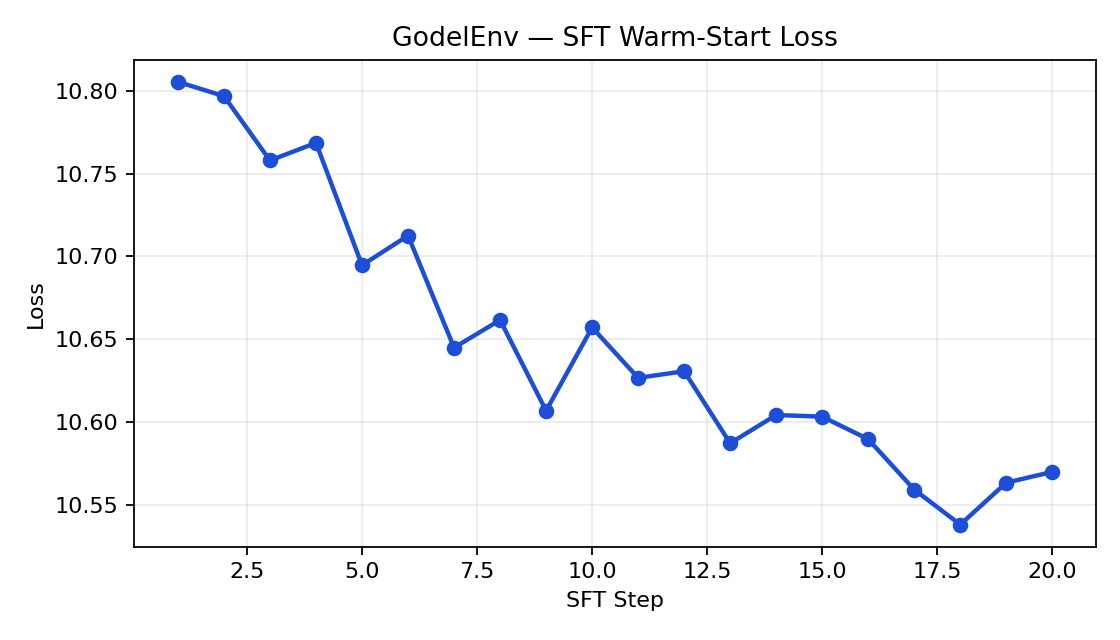


=== GRPO Reward Curve ===


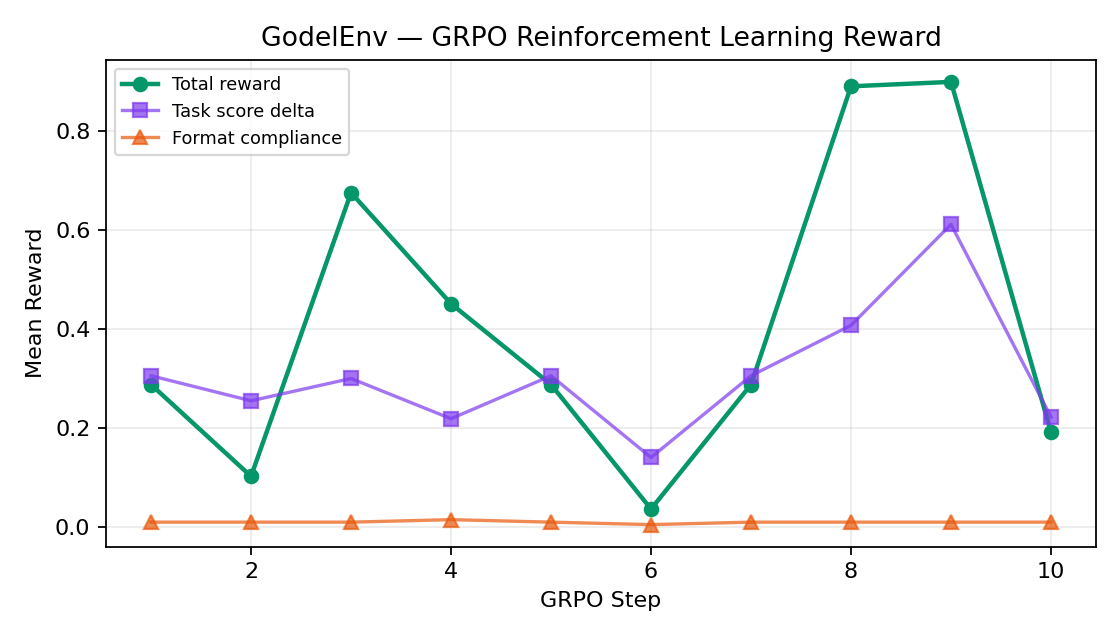


=== Before / After Training ===


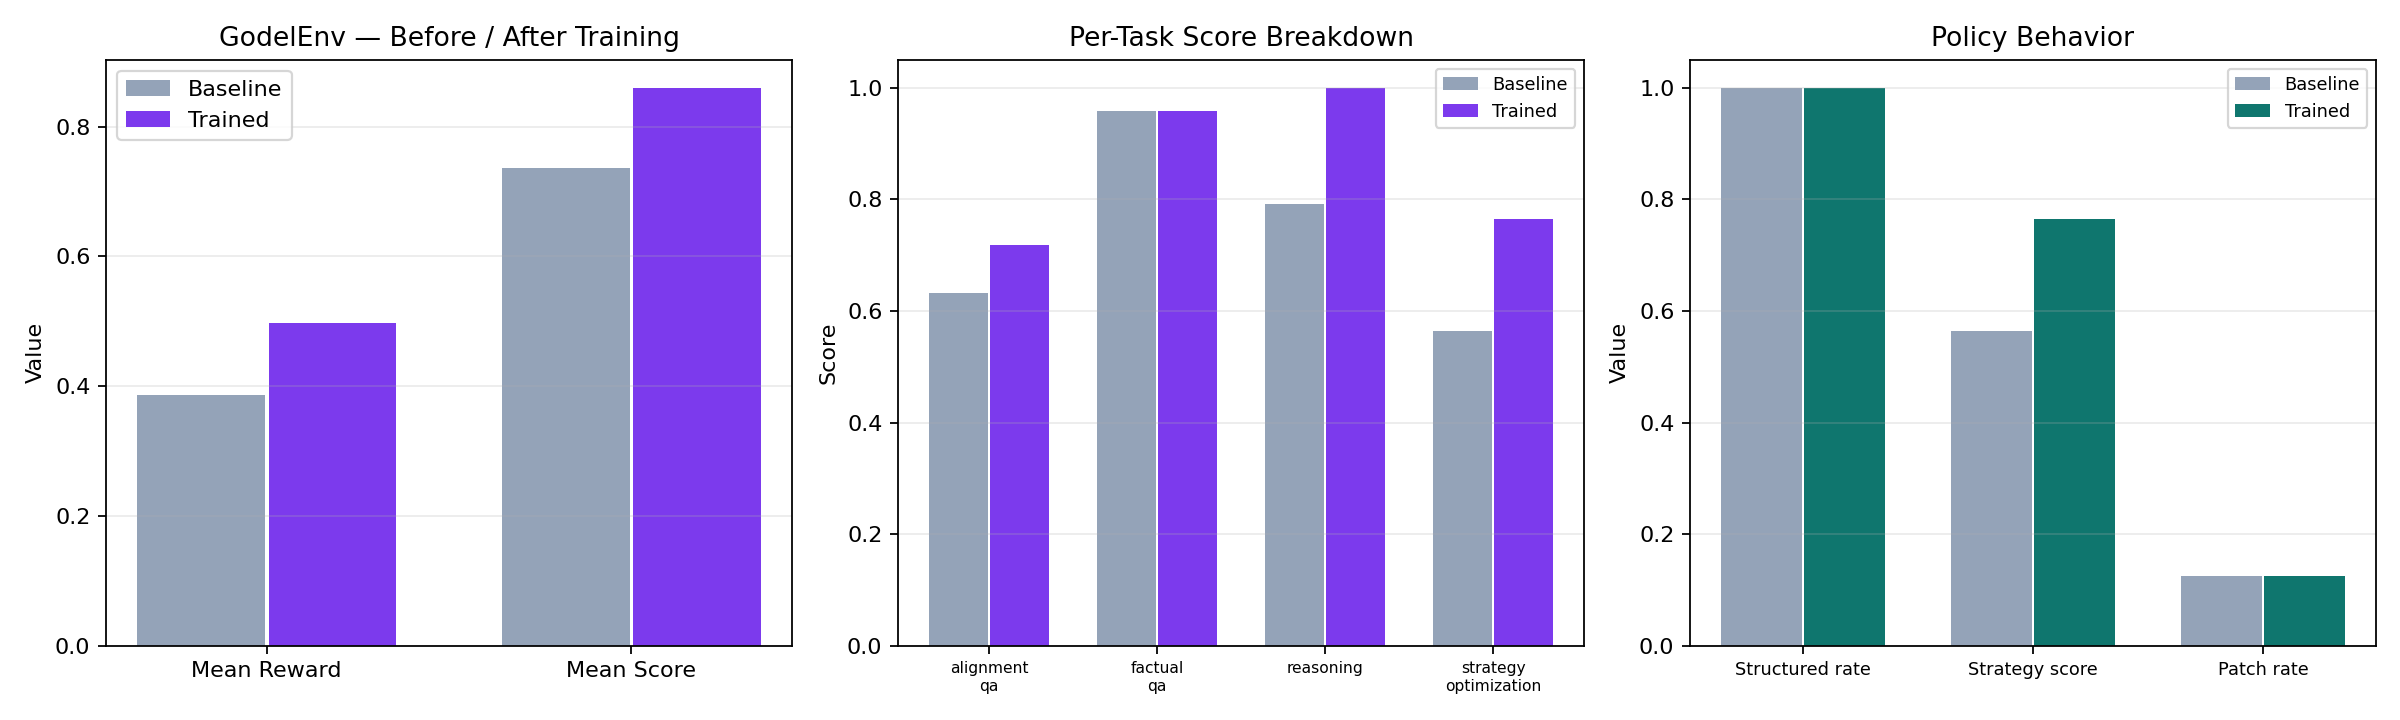

In [10]:
from IPython.display import Image, display

print("=== SFT Loss Curve ===")
display(Image(filename=str(plots["loss_curve"])))
print("\n=== GRPO Reward Curve ===")
display(Image(filename=str(plots["reward_curve"])))
print("\n=== Before / After Training ===")
display(Image(filename=str(before_after_path)))